# Assignment 5: Classification Showdown

Build and compare classification models on the Fashion-MNIST dataset.

## Setup

In [2]:
import os
import json
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
)
from xgboost import XGBClassifier

from helpers import load_fashion_mnist, plot_roc_curves, plot_confusion_matrix

# Create output directory
OUTPUT_DIR = "output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Setup complete!")

Setup complete!


---

## Part 1: Binary Classification

**Task:** Classify T-shirts (label 0) vs Trousers (label 1)

This is a straightforward binary classification task. Focus on:
- Filtering data to the target classes
- Proper train/test splitting with stratification
- Scaling features correctly (fit on train only!)

In [4]:
print("Part 1: Binary Classification")
print("-" * 40)

# Load the full dataset
X, y = load_fashion_mnist()

# Filter to only labels 0 and 1
# Hint: np.isin(y, [0, 1]) returns a boolean array where True means the label is 0 or 1
# Use this mask to index into X and y: X[mask], y[mask]
mask = np.isin(y, [0, 1])
X_filtered = X[mask] 
y_filtered = y[mask] 

# Train/test split with stratification
# Use test_size=0.2, random_state=42, stratify=y_filtered
X_train, X_test, y_train, y_test = train_test_split(
    X_filtered,
    y_filtered,
    test_size=0.2,
    random_state=42,
    stratify=y_filtered
)

# Scale features - fit on train, transform both
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) 
X_test_scaled = scaler.transform(X_test)

# Train LogisticRegression (use max_iter=1000, random_state=42)
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

# Evaluate
y_pred = model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

# Save results
results = {
    "task": "tshirt_vs_trouser",
    "accuracy": accuracy,
    "confusion_matrix": cm.tolist()  # Convert numpy array to list for JSON
}
with open(os.path.join(OUTPUT_DIR, "part1_results.json"), "w") as f:
    json.dump(results, f, indent=2)

print(f"Accuracy: {accuracy:.4f}")
print(f"Confusion Matrix:\n{cm}")

Part 1: Binary Classification
----------------------------------------
Accuracy: 0.9836
Confusion Matrix:
[[1371   29]
 [  17 1383]]


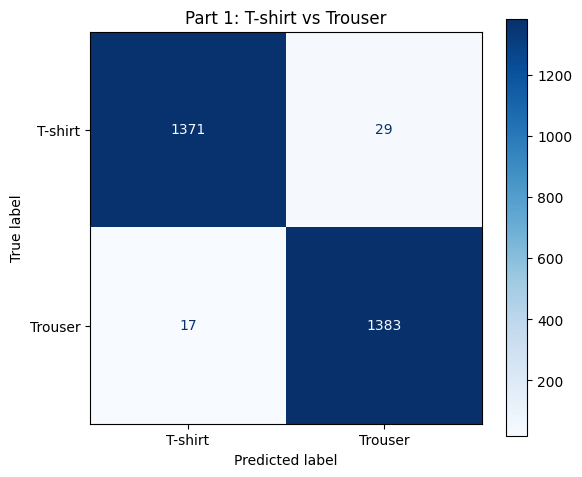

In [5]:
# Visualize results (provided - not part of assignment)
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['T-shirt', 'Trouser']).plot(ax=ax, cmap='Blues')
ax.set_title('Part 1: T-shirt vs Trouser')
plt.tight_layout()
plt.show()

---

## Part 2: Multi-class Classification with Cross-Validation

**Task:** Classify footwear types: Sandal (5) vs Sneaker (7) vs Ankle boot (9)

Compare three models using 5-fold cross-validation. Select the best model and evaluate on test set.

**Required outputs:**
- `output/part2_cv_results.csv` - columns: `model`, `fold`, `score`
- `output/part2_test_results.csv` - classification report as DataFrame

In [6]:
print("\nPart 2: Multi-class Classification with CV")
print("-" * 40)

X, y = load_fashion_mnist()

mask = np.isin(y, [5, 7, 9])
X_filtered = X[mask]
y_filtered = y[mask]

le = LabelEncoder()
y_encoded = le.fit_transform(y_filtered)

X_train, X_test, y_train, y_test = train_test_split(
    X_filtered,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

# Scale features (fit on train only!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Models to compare
models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, verbosity=0, n_jobs=-1)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_rows = []
mean_scores = {}

for model_name, model in models.items():
    scores = cross_val_score(
        model,
        X_train_scaled,
        y_train,
        cv=cv,
        scoring="accuracy"
    )
    mean_scores[model_name] = scores.mean()

    for fold_idx, score in enumerate(scores):
        cv_rows.append({
            "model": model_name,
            "fold": fold_idx,
            "score": score
        })

cv_df = pd.DataFrame(cv_rows)
cv_df.to_csv(os.path.join(OUTPUT_DIR, "part2_cv_results.csv"), index=False)

best_model_name = max(mean_scores, key=mean_scores.get)
best_model = models[best_model_name]

print(f"Best model by mean CV accuracy: {best_model_name} ({mean_scores[best_model_name]:.4f})")

best_model.fit(X_train_scaled, y_train)

y_pred = best_model.predict(X_test_scaled)

report_dict = classification_report(y_test, y_pred, output_dict=True)
report_df = (
    pd.DataFrame(report_dict)
    .transpose()
    .reset_index()
    .rename(columns={"index": "class"})
)


report_df.to_csv(os.path.join(OUTPUT_DIR, "part2_test_results.csv"), index=False)


Part 2: Multi-class Classification with CV
----------------------------------------
Best model by mean CV accuracy: XGBoost (0.9670)


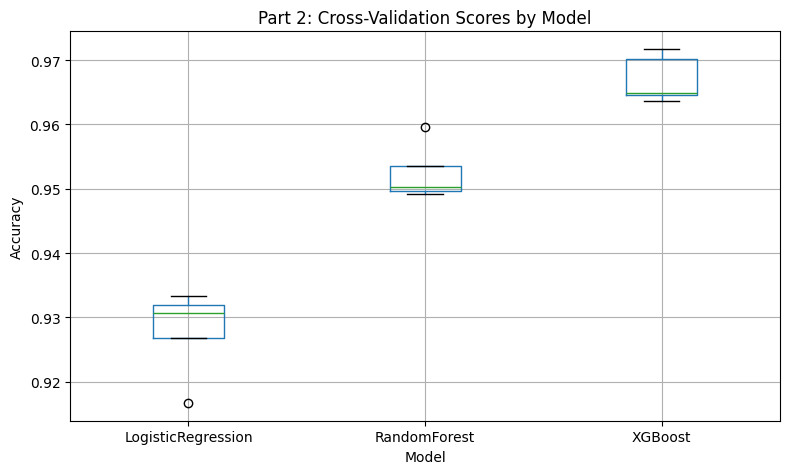

In [7]:
# Visualize CV results (provided - not part of assignment)
import matplotlib.pyplot as plt

try:
    fig, ax = plt.subplots(figsize=(8, 5))
    cv_df.boxplot(column='score', by='model', ax=ax)
    ax.set_title('Part 2: Cross-Validation Scores by Model')
    ax.set_xlabel('Model')
    ax.set_ylabel('Accuracy')
    plt.suptitle('')  # Remove automatic title
    plt.tight_layout()
    plt.show()
except NameError:
    print("cv_df not defined yet - complete the TODOs above first!")

---

## Part 3: Full Model Comparison Pipeline

**Task:** Classify Clothing vs Footwear (binary)

- **Clothing (0):** T-shirt, Trouser, Pullover, Dress, Coat, Shirt (labels 0-4, 6)
- **Footwear (1):** Sandal, Sneaker, Ankle boot (labels 5, 7, 9)
- **Exclude:** Bag (label 8)

Compare 3 models using AUC, generate ROC curves, evaluate best model.

**Required outputs:**
- `output/part3_cv_results.csv` - columns: `model`, `fold`, `auc`
- `output/part3_test_results.csv` - columns: `model`, `accuracy`, `auc`
- `output/part3_roc_curves.png` - use `plot_roc_curves()` from helpers
- `output/part3_confusion_matrix.png` - use `plot_confusion_matrix()` from helpers

In [8]:
print("\nPart 3: Full Model Comparison Pipeline")
print("-" * 40)

X, y = load_fashion_mnist()
mask = y != 8
X_filtered = X[mask]
y_filtered = y[mask]
footwear_labels = {5, 7, 9}
y_binary = np.isin(y_filtered, list(footwear_labels)).astype(int)
X_train, X_test, y_train, y_test = train_test_split(
    X_filtered,
    y_binary,
    test_size=0.2,
    random_state=42,
    stratify=y_binary
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, verbosity=0, n_jobs=-1)
}


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_rows = []
mean_auc = {}

for model_name, model in models.items():
    aucs = cross_val_score(
        model,
        X_train_scaled,
        y_train,
        cv=cv,
        scoring="roc_auc"
    )
    mean_auc[model_name] = aucs.mean()

    for fold_idx, auc in enumerate(aucs):
        cv_rows.append({
            "model": model_name,
            "fold": fold_idx,
            "auc": auc
        })

cv_df = pd.DataFrame(cv_rows)
cv_df.to_csv(os.path.join(OUTPUT_DIR, "part3_cv_results.csv"), index=False)

best_model_name = max(mean_auc, key=mean_auc.get)
best_model = models[best_model_name]
print(f"Best model by mean CV AUC: {best_model_name} ({mean_auc[best_model_name]:.4f})")

trained_models = {}
for model_name, model in models.items():
    model.fit(X_train_scaled, y_train)
    trained_models[model_name] = model

plot_roc_curves(
    trained_models,
    X_test_scaled,
    y_test,
    save_path=os.path.join(OUTPUT_DIR, "part3_roc_curves.png")
)

y_pred = trained_models[best_model_name].predict(X_test_scaled)

y_prob = trained_models[best_model_name].predict_proba(X_test_scaled)[:, 1]
test_accuracy = accuracy_score(y_test, y_pred)
test_auc = roc_auc_score(y_test, y_prob)

plot_confusion_matrix(
    y_test,
    y_pred,
    ["Clothing", "Footwear"],
    save_path=os.path.join(OUTPUT_DIR, "part3_confusion_matrix.png")
)

test_df = pd.DataFrame([{
    "model": best_model_name,
    "accuracy": test_accuracy,
    "auc": test_auc
}])
test_df.to_csv(os.path.join(OUTPUT_DIR, "part3_test_results.csv"), index=False)

print(f"Test Accuracy ({best_model_name}): {test_accuracy:.4f}")
print(f"Test AUC ({best_model_name}): {test_auc:.4f}")


Part 3: Full Model Comparison Pipeline
----------------------------------------
Best model by mean CV AUC: XGBoost (1.0000)
Test Accuracy (XGBoost): 0.9994
Test AUC (XGBoost): 1.0000


---

## Validation

In [9]:
# Run in terminal: pytest .github/tests/ -v
print("Run 'pytest .github/tests/ -v' in your terminal to check your work.")

Run 'pytest .github/tests/ -v' in your terminal to check your work.
